# 01. Native Data Understanding & Relational EDA

## 1. Business Objective
We must natively inspect all 7 OULAD datasets to guarantee complete transparency before feature engineering begins.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = '../data/raw/'
files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
datasets = {f.replace('.csv', ''): pd.read_csv(os.path.join(DATA_DIR, f)) for f in files}

## 2. Exhaustive Dataset Inspection
Iterating natively through all loaded DataFrames to print shapes, nulls, and duplicate counts.

In [2]:
for name, df in datasets.items():
    print(f"\n{'='*40}\n{name.upper()}\n{'='*40}")
    print(f"Shape: {df.shape}")
    print(f"Duplicates: {df.duplicated().sum()}")
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print("Missing Values:\n", nulls[nulls > 0])
    else:
        print("Missing Values: 0")


ASSESSMENTS
Shape: (206, 6)
Duplicates: 0
Missing Values:
 date    11
dtype: int64

COURSES
Shape: (22, 3)
Duplicates: 0
Missing Values: 0

STUDENTASSESSMENT
Shape: (173912, 5)
Duplicates: 0
Missing Values:
 score    173
dtype: int64

STUDENTINFO
Shape: (32593, 12)
Duplicates: 0
Missing Values:
 imd_band    1111
dtype: int64

STUDENTREGISTRATION
Shape: (32593, 5)
Duplicates: 0
Missing Values:
 date_registration         45
date_unregistration    22521
dtype: int64

STUDENTVLE
Shape: (10655280, 6)


Duplicates: 787170


Missing Values: 0

VLE
Shape: (6364, 6)
Duplicates: 0
Missing Values:
 week_from    5243
week_to      5243
dtype: int64


## 3. Explicit Relational Mapping
- `studentInfo.csv`: Base Demographic Table (`id_student`, `code_module`)
- `studentVle.csv`: Interaction Logs (`id_student`, `id_site`). MUST be aggregated by `id_student` BEFORE merging to base to prevent row explosion.
- `studentAssessment.csv`: Score Logs (`id_student`, `id_assessment`). MUST be aggregated by `id_student` BEFORE merging.

## 4. Visualizing the Target Distribution
Plotting the class imbalance natively to justify SMOTE in Notebook 03.

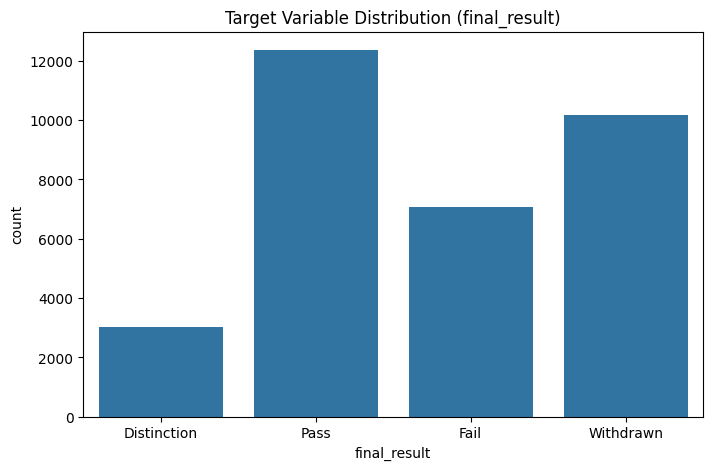

In [3]:
plt.figure(figsize=(8,5))
sns.countplot(data=datasets['studentInfo'], x='final_result', order=['Distinction', 'Pass', 'Fail', 'Withdrawn'])
plt.title('Target Variable Distribution (final_result)')
plt.show()